# Data Profiling: Chlorophyll-a Concentration (Sarasota, Dataset 2)

`ChlorophyllaConcentrationSarasota_Dataset2.csv` — a second NOAA CoastWatch-style satellite-derived chlorophyll-a product over the Sarasota-area waters.

**Goal:** Apply the same profiling approach used for `florida_cyanotoxins` and `habsos_cellcounts` (row counts, column types, missing values, duplicates, invalid values, outliers) to this dataset.

**Note:** This file was initially assumed to be a duplicate batch of `ChlorophyllaConcentrationSarasota.csv` (profiled in [data_profiling_chlorophyll_dataset1.ipynb](./data_profiling_chlorophyll_dataset1.ipynb)). Profiling shows differences from Dataset 1:
- No `altitude` column (Dataset 1 has one, always `0.0`).
- Different grid: 1,554 grid points vs. 1,886 in Dataset 1.
- Different time coverage: 2010-01-01 to 2022-05-31, vs. 2020-06-15 to 2026-09-05 in Dataset 1.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

DATA_DIR = "../data"
CHLOROPHYLL_PATH = f"{DATA_DIR}/ChlorophyllaConcentrationSarasota_Dataset2.csv"

# ERDDAP export: row 0 is the header, row 1 is a units row, data starts at row 2.
UNITS_ROW = [1]

In [2]:
def profile_dataset(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """Return a per-column profile: dtype, inferred kind, missingness, uniqueness."""
    n_rows = len(df)
    rows = []
    for col in df.columns:
        s = df[col]
        n_missing = s.isna().sum()
        n_unique = s.nunique(dropna=True)
        if pd.api.types.is_numeric_dtype(s):
            kind = "numeric"
        elif pd.api.types.is_bool_dtype(s):
            kind = "boolean"
        else:
            kind = "categorical/text"
        rows.append({
            "column": col,
            "dtype": str(s.dtype),
            "kind": kind,
            "n_missing": n_missing,
            "pct_missing": round(100 * n_missing / n_rows, 2) if n_rows else 0,
            "n_unique": n_unique,
            "sample_values": list(s.dropna().unique()[:3]),
        })
    profile = pd.DataFrame(rows).sort_values("pct_missing", ascending=False).reset_index(drop=True)
    print(f"[{name}] shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
    print(f"[{name}] exact duplicate rows: {df.duplicated().sum():,}")
    return profile


def lon_360_to_180(lon: pd.Series) -> pd.Series:
    """ERDDAP grids often use 0-360 longitude convention; convert to standard -180..180."""
    return ((lon + 180) % 360) - 180

## 1. Load and high-level overview

In [3]:
chl2 = pd.read_csv(CHLOROPHYLL_PATH, skiprows=UNITS_ROW, low_memory=False)
chl2.head()

,time,latitude,longitude,chlor_a
0,2010-01-01T12:00:00Z,28.020832,276.47920,NaN
1,2010-01-01T12:00:00Z,28.020832,276.52084,NaN
2,2010-01-01T12:00:00Z,28.020832,276.56250,NaN
3,2010-01-01T12:00:00Z,28.020832,276.60420,NaN
4,2010-01-01T12:00:00Z,28.020832,276.64584,NaN


In [4]:
chl2_profile = profile_dataset(chl2, "ChlorophyllaConcentrationSarasota_Dataset2")
chl2_profile

[ChlorophyllaConcentrationSarasota_Dataset2] shape: 7,010,094 rows x 4 columns


[ChlorophyllaConcentrationSarasota_Dataset2] exact duplicate rows: 0


,column,dtype,kind,n_missing,pct_missing,n_unique,sample_values
0,chlor_a,float64,numeric,5663976,80.8,1270028,"[0.7306708, 0.76635367, 0.8396759]"
1,time,str,categorical/text,0,0.0,4511,"[2010-01-01T12:00:00Z, 2010-01-02T12:00:00Z, 2..."
2,latitude,float64,numeric,0,0.0,37,"[28.020832, 27.979164, 27.937498]"
3,longitude,float64,numeric,0,0.0,42,"[276.4792, 276.52084, 276.5625]"


## 2. Numeric vs. categorical columns

Only 4 columns here (`time`, `latitude`, `longitude`, `chlor_a`) — unlike Dataset 1, there is no `altitude` column at all.

In [5]:
chl2_numeric_cols = chl2_profile.loc[chl2_profile["kind"] == "numeric", "column"].tolist()
chl2_categorical_cols = chl2_profile.loc[chl2_profile["kind"] != "numeric", "column"].tolist()
print(f"Numeric columns ({len(chl2_numeric_cols)}): {chl2_numeric_cols}")
print(f"Categorical/text columns ({len(chl2_categorical_cols)}): {chl2_categorical_cols}")

Numeric columns (3): ['chlor_a', 'latitude', 'longitude']
Categorical/text columns (1): ['time']


## 3. Missing values

Same expectation as Dataset 1: satellite chlorophyll-a can't see through cloud cover, so missing `chlor_a` values are expected.

In [6]:
print("Missing values:\n", chl2.isna().sum())
print(f"\npct chlor_a missing: {100 * chl2['chlor_a'].isna().mean():.1f}%")
print("(expected: satellite chlorophyll-a is unavailable under cloud cover / no valid retrieval)")

Missing values:
 time               0
latitude           0
longitude          0
chlor_a      5663976
dtype: int64

pct chlor_a missing: 80.8%
(expected: satellite chlorophyll-a is unavailable under cloud cover / no valid retrieval)


## 4. Duplicates

In [7]:
print("Exact duplicate rows:", chl2.duplicated().sum())

n_grid_points = chl2[["latitude", "longitude"]].drop_duplicates().shape[0]
n_timestamps = chl2["time"].nunique()
print(f"\nUnique (lat, lon) grid points: {n_grid_points:,}")
print(f"Unique timestamps: {n_timestamps:,}")
print(f"grid_points x timestamps = {n_grid_points * n_timestamps:,} vs. actual rows = {len(chl2):,}")

Exact duplicate rows: 0



Unique (lat, lon) grid points: 1,554
Unique timestamps: 4,511
grid_points x timestamps = 7,010,094 vs. actual rows = 7,010,094


## 5. Invalid values

In [8]:
chl2["time_parsed"] = pd.to_datetime(chl2["time"], errors="coerce")
print("Parsed date range:", chl2["time_parsed"].min(), "to", chl2["time_parsed"].max())
print("Rows where date failed to parse:", chl2["time_parsed"].isna().sum())

print("\nRaw latitude range:", chl2["latitude"].min(), "to", chl2["latitude"].max())
print("Raw longitude range:", chl2["longitude"].min(), "to", chl2["longitude"].max())
chl2["longitude_180"] = lon_360_to_180(chl2["longitude"])
print("Converted longitude range:", chl2["longitude_180"].min(), "to", chl2["longitude_180"].max())

print("\nNegative chlor_a values:", (chl2["chlor_a"] < 0).sum())
print("chlor_a == 0 exactly:", (chl2["chlor_a"] == 0).sum())
print("chlor_a stats:\n", chl2["chlor_a"].describe())

Parsed date range: 2010-01-01 12:00:00+00:00 to 2022-05-31 12:00:00+00:00
Rows where date failed to parse: 0

Raw latitude range: 26.520832 to 28.020832
Raw longitude range: 276.4792 to 278.1875


Converted longitude range: -83.52080000000001 to -81.8125

Negative chlor_a values: 0
chlor_a == 0 exactly: 0


chlor_a stats:
 count    1.346118e+06
mean     1.231273e+00
std      3.514223e+00
min      6.149622e-02
25%      2.476688e-01
50%      4.323958e-01
75%      9.591682e-01
max      9.990617e+01
Name: chlor_a, dtype: float64


## 6. Outliers

Same right-skewed shape as Dataset 1 (values from ~0.06 to ~100 mg/m^3), so outliers are assessed on a log scale.

IQR upper bound (log1p scale): 1.35 -> raw mg/m^3: 2.86
Rows above upper bound: 102012 (7.58% of non-missing rows)
Max observed value: 99.91 mg/m^3


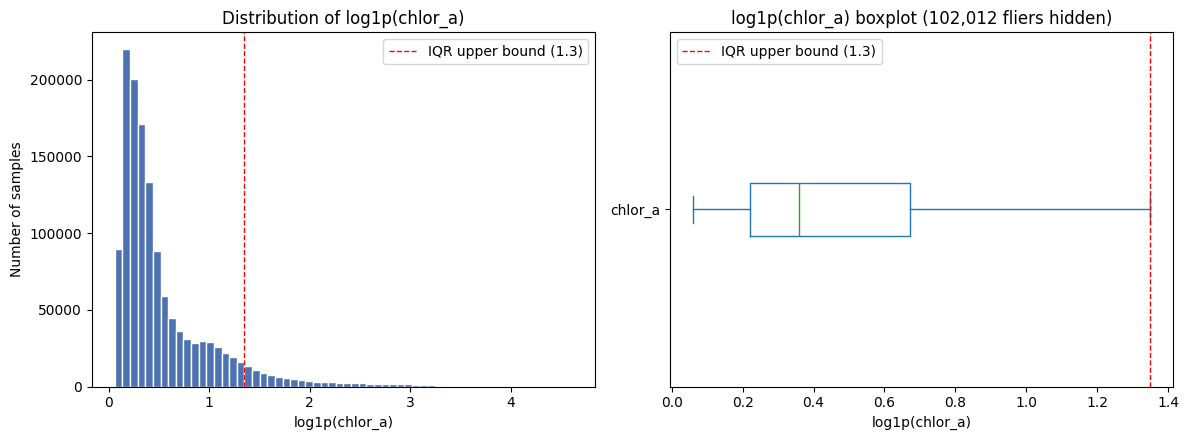

In [9]:
valid_chl2 = chl2["chlor_a"].dropna()
log_chl2 = np.log1p(valid_chl2)
q1, q3 = log_chl2.quantile(0.25), log_chl2.quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr
n_outliers = int((log_chl2 > upper).sum())
print(f"IQR upper bound (log1p scale): {upper:.2f} -> raw mg/m^3: {np.expm1(upper):.2f}")
print(f"Rows above upper bound: {n_outliers} ({100 * n_outliers / len(valid_chl2):.2f}% of non-missing rows)")
print(f"Max observed value: {valid_chl2.max():.2f} mg/m^3")

# Fliers are hidden (showfliers=False): with this many points beyond the IQR bound, plotting each
# as a marker overplots into a solid smear rather than a readable boxplot.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(log_chl2, bins=60, color="#4C72B0", edgecolor="white")
axes[0].axvline(upper, color="red", linestyle="--", linewidth=1, label=f"IQR upper bound ({upper:.1f})")
axes[0].set_xlabel("log1p(chlor_a)")
axes[0].set_ylabel("Number of samples")
axes[0].set_title("Distribution of log1p(chlor_a)")
axes[0].legend()

log_chl2.plot(kind="box", vert=False, ax=axes[1], showfliers=False)
axes[1].axvline(upper, color="red", linestyle="--", linewidth=1, label=f"IQR upper bound ({upper:.1f})")
axes[1].set_xlabel("log1p(chlor_a)")
axes[1].set_title(f"log1p(chlor_a) boxplot ({n_outliers:,} fliers hidden)")
axes[1].legend()
plt.tight_layout()
plt.show()